In [13]:
import sympy as sp
from sympy import *
# 1. Define your symbolic variables
# We tell Python these are real, positive numbers so it doesn't give us imaginary roots
r, M = sp.symbols('r M', positive=True, real=True)
A = sp.symbols('A')
b = sp.symbols('b')
v = sp.symbols('v')
dphi_dr = sp.symbols('dphi_dr')

# 2. Define the lapse function f(r) for Schwarzschild
f_r = 1 - (2*M / r) - (A*r**2)/3

# 3. Define the Effective Potential V(r)
# Based on the exact equation you extracted from your PDF
V_r = (1 / r**2) * f_r

# 4. Find the Photon Sphere (r_ph)
# Take the derivative of V(r) with respect to r
dV_dr = sp.diff(V_r, r)

# Set the derivative to 0 and solve for r
# This returns a list of solutions, we take the first valid one
r_ph_solutions = sp.solve(dV_dr, r)
r_ph = r_ph_solutions[0]

print(f"Photon Sphere radius (r_ph): {r_ph}") # Should output 3*M
display(Eq(r,r_ph))
print_latex(Eq(r,r_ph))

# 5. Calculate the Critical Impact Parameter (b_crit / Shadow Radius)
# Plug r_ph back into V(r) to find the maximum potential barrier
V_max = V_r.subs(r, r_ph)

# The shadow radius is b_crit = 1 / sqrt(V_max)
b_crit = 1 / sp.sqrt(V_max)

print(f"Critical Impact Parameter (b_crit): {b_crit}") # Should output 3*sqrt(3)*M
display(Eq(b,b_crit))
print_latex(Eq(b,b_crit))

Photon Sphere radius (r_ph): 3*M


Eq(r, 3*M)

r = 3 M
Critical Impact Parameter (b_crit): 3*M/sqrt(-3*A*M**2 + 1/3)


Eq(b, 3*M/sqrt(-3*A*M**2 + 1/3))

b = \frac{3 M}{\sqrt{- 3 A M^{2} + \frac{1}{3}}}


Matplotlib is building the font cache; this may take a moment.
2026-04-17 02:12:33.686 system_profiler[73136:1266668] CoreText note: Client requested name ".AlBayanPUA", it will get Times-Roman rather than the intended font. All system UI font access should be through proper APIs such as CTFontCreateUIFontForLanguage() or +[NSFont systemFontOfSize:].
2026-04-17 02:12:33.686 system_profiler[73136:1266668] CoreText note: Set a breakpoint on CTFontLogSystemFontNameRequest to debug.
2026-04-17 02:12:33.696 system_profiler[73136:1266668] CoreText note: Client requested name ".AlBayanPUA-Bold", it will get Times-Roman rather than the intended font. All system UI font access should be through proper APIs such as CTFontCreateUIFontForLanguage() or +[NSFont systemFontOfSize:].
2026-04-17 02:12:33.704 system_profiler[73136:1266668] CoreText note: Client requested name ".AlNilePUA", it will get Times-Roman rather than the intended font. All system UI font access should be through proper APIs such

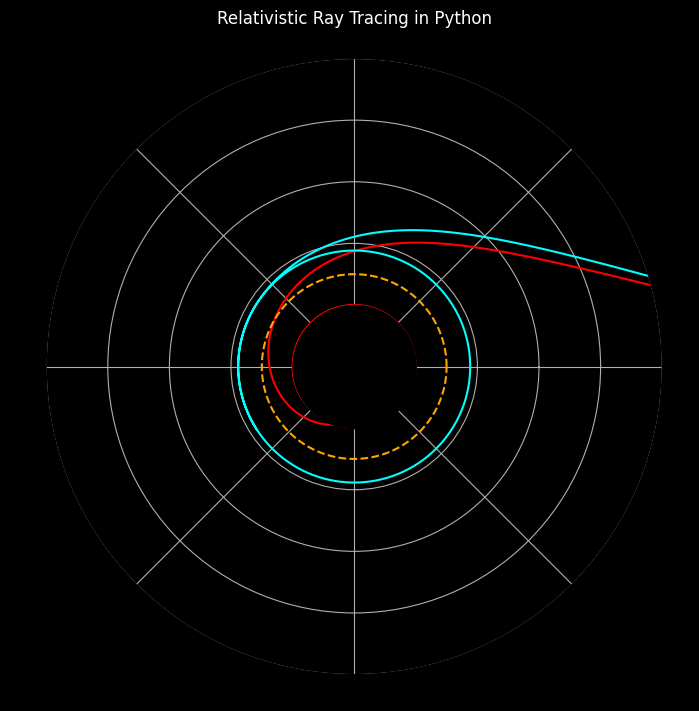

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Set our constants (Let M = 1 for simplicity in plotting)
M = 1.0
b_crit = 3 * np.sqrt(3) * M  # ≈ 5.196

# 2. Define the Differential Equation
# This function tells Python how the radius (r) changes as the angle (phi) changes
def ray_equation(phi, r, b):
    # If the photon crosses the event horizon (r < 2M), stop the math
    if r < 2.01 * M:
        return 0 
    
    # f(r) and V(r) for Schwarzschild
    f_r = 1 - (2*M / r)
    V_r = f_r / (r**2)
    
    # The ODE derived from your paper: dr/d(phi) = - r^2 * sqrt(1/b^2 - V(r))
    # We use negative because we are tracing light falling INWARD from infinity
    dr_dphi = - (r**2) * np.sqrt(max(0, (1 / b**2) - V_r))
    return dr_dphi

# 3. Simulate multiple photons with different impact parameters (b)
# Let's shoot one photon that gets sucked in, and one that escapes
impact_parameters = [5.0, 5.5] # 5.0 is < b_crit (falls in), 5.5 is > b_crit (escapes)

phi_span = (0, 10) # Track the photon for 10 radians of rotation
r_initial = [20.0] # Start the photon far away at r = 20M

plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.subplot(111, projection='polar') # Use polar coordinates for space
ax.set_facecolor('black')

# 4. Run the ODE solver and plot
for b in impact_parameters:
    # Solve the path
    solution = solve_ivp(ray_equation, phi_span, r_initial, args=(b,), 
                         dense_output=True, max_step=0.05)
    
    # Extract the angles and radii
    phi_values = solution.t
    r_values = solution.y[0]
    
    # Choose color based on whether it fell in or escaped
    color = 'red' if b < b_crit else 'cyan'
    ax.plot(phi_values, r_values, color=color, linewidth=1.5)

# 5. Draw the Black Hole Event Horizon and Photon Sphere
circle_phi = np.linspace(0, 2*np.pi, 100)
ax.fill_between(circle_phi, 0, 2*M, color='black', zorder=5) # Event Horizon
ax.plot(circle_phi, np.full_like(circle_phi, 3*M), color='orange', linestyle='--', label="Photon Sphere")

ax.set_ylim(0, 10)
plt.title("Relativistic Ray Tracing in Python", color='white')
plt.show()